In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.shape

(6607, 20)

In [5]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

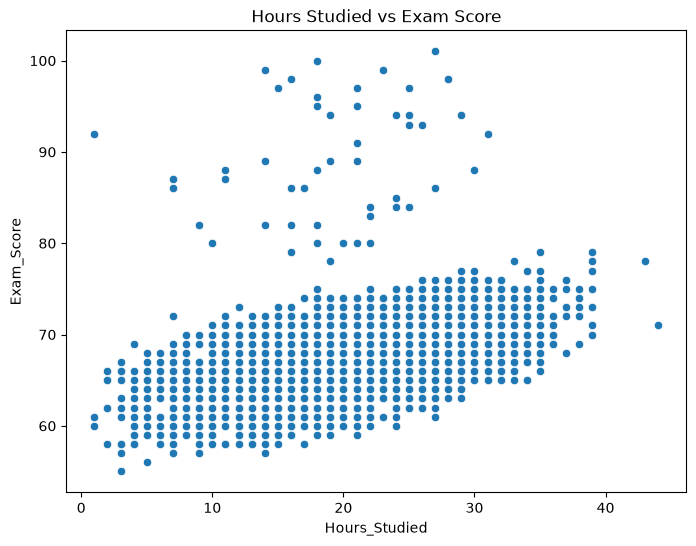

In [8]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)
plt.title("Hours Studied vs Exam Score")
plt.show()

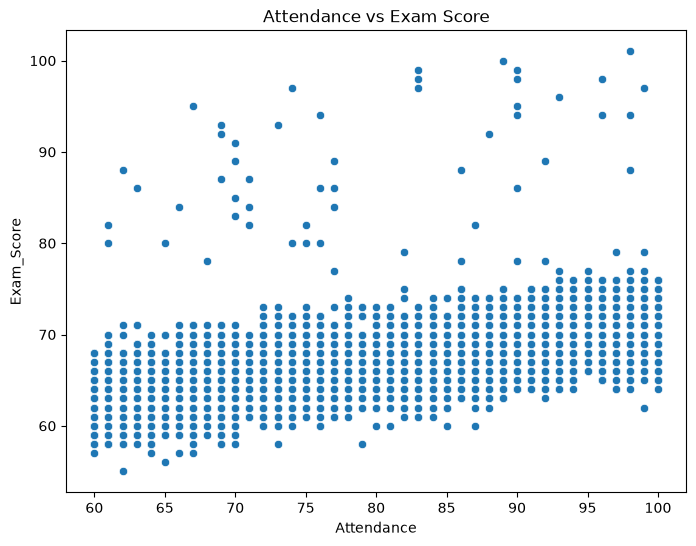

In [9]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Attendance', y='Exam_Score', data=df)
plt.title("Attendance vs Exam Score")
plt.show()

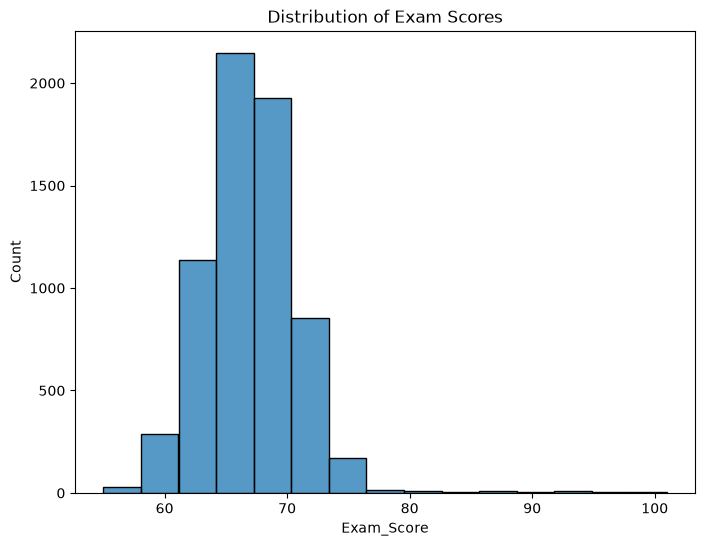

In [10]:
plt.figure(figsize=(8,6))
sns.histplot(df['Exam_Score'], bins=15)
plt.title("Distribution of Exam Scores")
plt.show()

In [11]:
corr = df.corr(numeric_only=True)

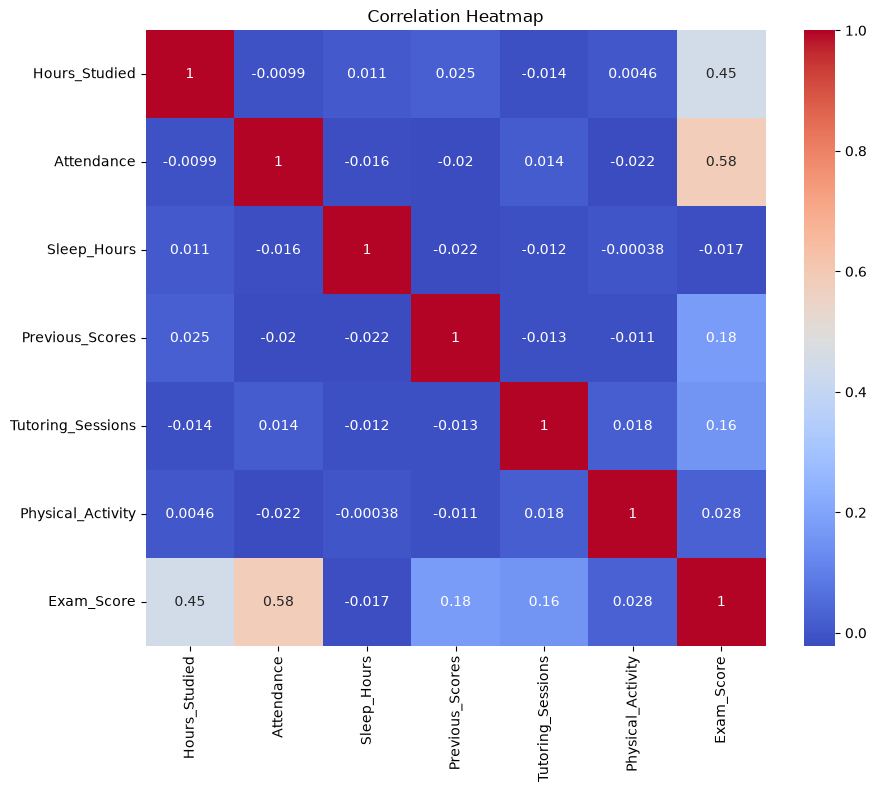

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

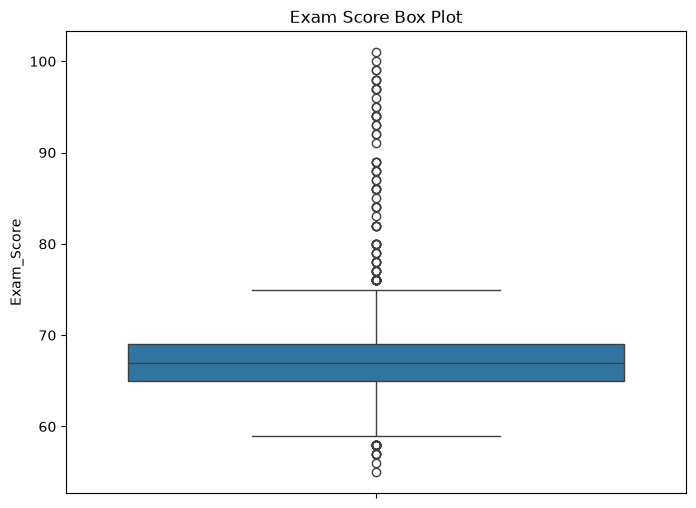

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(y=df['Exam_Score'])
plt.title("Exam Score Box Plot")
plt.show()

In [14]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [15]:
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(
    df["Teacher_Quality"].mode()[0]
)

df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(
    df["Parental_Education_Level"].mode()[0]
)

df["Distance_from_Home"] = df["Distance_from_Home"].fillna(
    df["Distance_from_Home"].mode()[0]
)

In [16]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include=['object', 'string']).columns
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X = df.drop("Exam_Score", axis=1)

y = df["Exam_Score"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5285, 19)
(1322, 19)
(5285,)
(1322,)


In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
model = LinearRegression()


In [24]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](19,)","[ 0.29, 0.2 ,-0.45,..., 0.18, 0.47,-0.02]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](19,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Parental_Education_Level','Distance_from_Home','Gender']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,40.13
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,19
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)


In [25]:
y_pred = model.predict(X_test)

In [26]:
print(y_pred[:10])

[65.21661267 67.44841105 69.82970337 67.28780452 66.75815888 68.12362991
 71.34655218 67.88775689 70.61053195 69.73680481]


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [28]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.0155490830845968


In [29]:
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 4.399275539170952


In [30]:
rmse = np.sqrt(mse)
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 2.0974450026570306


In [31]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6887688020307758


In [32]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

                       Feature  Coefficient
0                Hours_Studied     0.288626
1                   Attendance     0.197815
2         Parental_Involvement    -0.446969
3          Access_to_Resources    -0.404436
4   Extracurricular_Activities     0.569081
5                  Sleep_Hours    -0.029158
6              Previous_Scores     0.048123
7             Motivation_Level    -0.154532
8              Internet_Access     0.967763
9            Tutoring_Sessions     0.502380
10               Family_Income    -0.166623
11             Teacher_Quality    -0.237587
12                 School_Type    -0.033381
13              Peer_Influence     0.532565
14           Physical_Activity     0.172583
15       Learning_Disabilities    -0.874608
16    Parental_Education_Level     0.177876
17          Distance_from_Home     0.467132
18                      Gender    -0.018779


In [33]:
coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

                       Feature  Coefficient
8              Internet_Access     0.967763
4   Extracurricular_Activities     0.569081
13              Peer_Influence     0.532565
9            Tutoring_Sessions     0.502380
17          Distance_from_Home     0.467132
0                Hours_Studied     0.288626
1                   Attendance     0.197815
16    Parental_Education_Level     0.177876
14           Physical_Activity     0.172583
6              Previous_Scores     0.048123
18                      Gender    -0.018779
5                  Sleep_Hours    -0.029158
12                 School_Type    -0.033381
7             Motivation_Level    -0.154532
10               Family_Income    -0.166623
11             Teacher_Quality    -0.237587
3          Access_to_Resources    -0.404436
2         Parental_Involvement    -0.446969
15       Learning_Disabilities    -0.874608


In [34]:
print(model.intercept_)

40.13036112465204


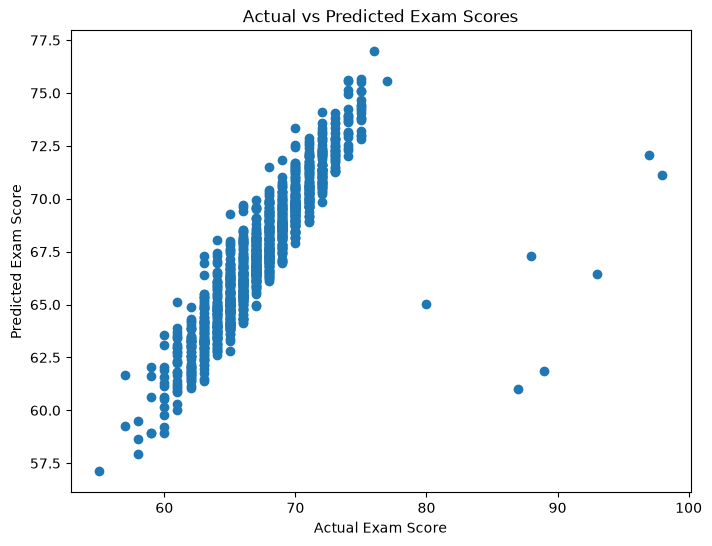

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

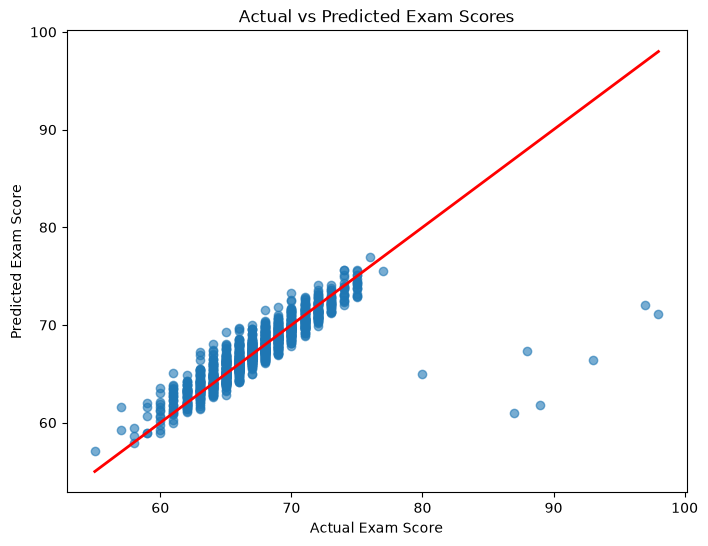

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Ideal prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red",
         linewidth=2)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

plt.show()

In [37]:
print("Jupyter is working!")

Jupyter is working!


In [38]:
print(X.columns.tolist())

['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [41]:
import pandas as pd

print("===== Student Performance Predictor =====")
print("\nEnter the encoded values for the student.\n")

hours_studied = float(input("Hours Studied: "))
attendance = float(input("Attendance (%): "))
parental_involvement = float(input("Parental Involvement: "))
access_to_resources = float(input("Access to Resources: "))
extracurricular = float(input("Extracurricular Activities: "))
sleep_hours = float(input("Sleep Hours: "))
previous_scores = float(input("Previous Scores: "))
motivation = float(input("Motivation Level: "))
internet = float(input("Internet Access: "))
tutoring = float(input("Tutoring Sessions: "))
family_income = float(input("Family Income: "))
teacher_quality = float(input("Teacher Quality: "))
school_type = float(input("School Type: "))
peer_influence = float(input("Peer Influence: "))
physical_activity = float(input("Physical Activity: "))
learning_disabilities = float(input("Learning Disabilities: "))
parent_education = float(input("Parental Education Level: "))
distance = float(input("Distance from Home: "))
gender = float(input("Gender: "))

new_student = pd.DataFrame([[

    hours_studied,
    attendance,
    parental_involvement,
    access_to_resources,
    extracurricular,
    sleep_hours,
    previous_scores,
    motivation,
    internet,
    tutoring,
    family_income,
    teacher_quality,
    school_type,
    peer_influence,
    physical_activity,
    learning_disabilities,
    parent_education,
    distance,
    gender

]], columns=X.columns)

prediction = model.predict(new_student)

print("\nPredicted Exam Score:", round(prediction[0], 2))

===== Student Performance Predictor =====

Enter the encoded values for the student.



Hours Studied:  7
Attendance (%):  70
Parental Involvement:  yes


ValueError: could not convert string to float: 'yes'

In [42]:
## Feature Selection and Model Retraining

In [43]:
selected_features = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Sleep_Hours",
    "Motivation_Level",
    "Internet_Access",
    "Tutoring_Sessions",
    "Teacher_Quality"
]

X = df[selected_features]
y = df["Exam_Score"]

print(X.head())

   Hours_Studied  Attendance  Previous_Scores  Sleep_Hours  Motivation_Level  \
0             23          84               73            7                 1   
1             19          64               59            8                 1   
2             24          98               91            7                 2   
3             29          89               98            8                 2   
4             19          92               65            6                 2   

   Internet_Access  Tutoring_Sessions  Teacher_Quality  
0                1                  0                2  
1                1                  2                2  
2                1                  2                2  
3                1                  1                2  
4                1                  3                0  


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.29, 0.2 , 0.05,..., 0.92, 0.51,-0.25]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Hours_Studied','Attendance','Previous_Scores',...,'Internet_Access', 'Tutoring_Sessions','Teacher_Quality']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,41.11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 1.2432241067608563
Mean Squared Error: 5.003021920769672
Root Mean Squared Error: 2.2367435974580707
R² Score: 0.6460561535636683


In [48]:
import pandas as pd

print("=" * 45)
print("      STUDENT PERFORMANCE PREDICTOR")
print("=" * 45)

hours = float(input("Hours Studied: "))
attendance = float(input("Attendance (%): "))
previous = float(input("Previous Scores: "))
sleep = float(input("Sleep Hours: "))

print("\nMotivation Level")
print("0 = Low")
print("1 = Medium")
print("2 = High")
motivation = int(input("Enter your choice: "))

print("\nInternet Access")
print("0 = No")
print("1 = Yes")
internet = int(input("Enter your choice: "))

tutoring = int(input("\nTutoring Sessions: "))

print("\nTeacher Quality")
print("0 = Low")
print("1 = Medium")
print("2 = High")
teacher = int(input("Enter your choice: "))

new_student = pd.DataFrame([[
    hours,
    attendance,
    previous,
    sleep,
    motivation,
    internet,
    tutoring,
    teacher
]], columns=X.columns)

prediction = model.predict(new_student)

print("\n" + "=" * 45)
print(f"Predicted Exam Score: {prediction[0]:.2f}")
print("=" * 45)

      STUDENT PERFORMANCE PREDICTOR


Hours Studied:  3
Attendance (%):  60
Previous Scores:  60
Sleep Hours:  8



Motivation Level
0 = Low
1 = Medium
2 = High


Enter your choice:  1



Internet Access
0 = No
1 = Yes


Enter your choice:  1

Tutoring Sessions:  4



Teacher Quality
0 = Low
1 = Medium
2 = High


Enter your choice:  1



Predicted Exam Score: 59.06


In [49]:
score = prediction[0]

print("\n" + "=" * 45)
print(f"Predicted Exam Score: {score:.2f}")

if score >= 90:
    print("Performance: Excellent 🌟")
elif score >= 75:
    print("Performance: Good 👍")
elif score >= 60:
    print("Performance: Average 🙂")
else:
    print("Performance: Needs Improvement 📚")

print("=" * 45)


Predicted Exam Score: 59.06
Performance: Needs Improvement 📚
